### Environment Setup
Importing essential libraries for data manipulation, text preprocessing, visualization, and machine learning.

In [2]:

import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 500)

import re
import unicodedata
import html
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Data Acquisition
Loading the language identification dataset from Hugging Face and sampling 100 rows for initial inspection.

In [3]:

splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': 'test.csv'}
df_train = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["train"])
df_val = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["validation"])
df_test = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["test"])


df_train.sample(100)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,labels,text
1016,ar,"نعم , انت تعلم انه من الصعب ان اقول ان تغيرت الامور هناك لذا"
68773,ar,على اية حال انا لا اعرف انا فقط
7006,pl,Co najmniej dwóch zabitych w południowym Egipcie
66669,sw,Na in a like a ooh don aje kama pyrex ama kitu kama ile bakuli ya aina wange kwa microwave
51118,ur,کیا تمہارے پاس بچوں کے لیے بیٹے ہیں ؟
51163,hi,"अन ् य , अधिक चुनौतीपूर ् ण विकल ् प , जिसके लिए आपको मार ् गदर ् शन की मदद करना चाहिए , आपको माउंट ( 1,576 मी / 5,169 फुट ) माउंट जस ् सर ( 1,696 मीटर / 5,562 फुट ) के लिए ले जाना चाहिए , और माउंट beremban ( 1,841 एम / 6,040 फुट )"
10357,pl,Niebieski ptak siedzący na rękawiczce.
33306,el,Το τμήμα 717 ( Β ) εγκρίνει επίσης σαφώς τη μελέτη αυτή .
48368,zh,1. 它让我忽然想起螺丝刀的刀头原本的样子，也就是关于一点点物理知识的样子。 2. 传说中的磁力，听说过没见过，以前在机箱里找螺丝都得用镊子。
56335,th,เอ่อ ฉัน อยู่ ที่ monterey california ตอนนี้


### Dataset Diagnostics
Printing dataset structure, checking for null values, and verifying dimensions of all data splits.

In [4]:
print("--- Dataset Info ---")
print(df_train.info())
print("\n--- Missing Values ---")
print(df_train.isnull().sum())

print("Train shape: ",df_train.shape)
print("Test shape: ",df_test.shape)
print("Validation shape: ",df_val.shape)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB
None

--- Missing Values ---
labels    0
text      0
dtype: int64
Train shape:  (70000, 2)
Test shape:  (10000, 2)
Validation shape:  (10000, 2)


**Conclusion:** The dataset is clean with no missing values and consists of 70,000 training samples and 10,000 samples for both validation and testing.

### Label Identification
Identifying and listing all unique language labels present in the training set.

In [5]:
languages = df_train['labels'].unique()
print(f"Languages: {languages}")

Languages: ['pt' 'bg' 'zh' 'th' 'ru' 'pl' 'ur' 'sw' 'tr' 'es' 'ar' 'it' 'hi' 'de'
 'el' 'nl' 'fr' 'vi' 'en' 'ja']


**Conclusion:** There are 20 distinct languages represented in this dataset.

Languages

The Language Identification dataset contains text in 20 languages, which are:

**arabic** (ar), **bulgarian** (bg), **german** (de), **modern greek** (el), **english** (en), **spanish** (es), **french** (fr), **hindi** (hi), **italian** (it), **japanese** (ja), **dutch** (nl), **polish** (pl), **portuguese** (pt), **russian** (ru), **swahili** (sw), **thai** (th), **turkish** (tr), **urdu** (ur), **vietnamese** (vi), and **chinese** (zh)

### Class Distribution
Calculating language frequencies and visualizing the balance of classes with a bar chart.


--- Class Distribution ---


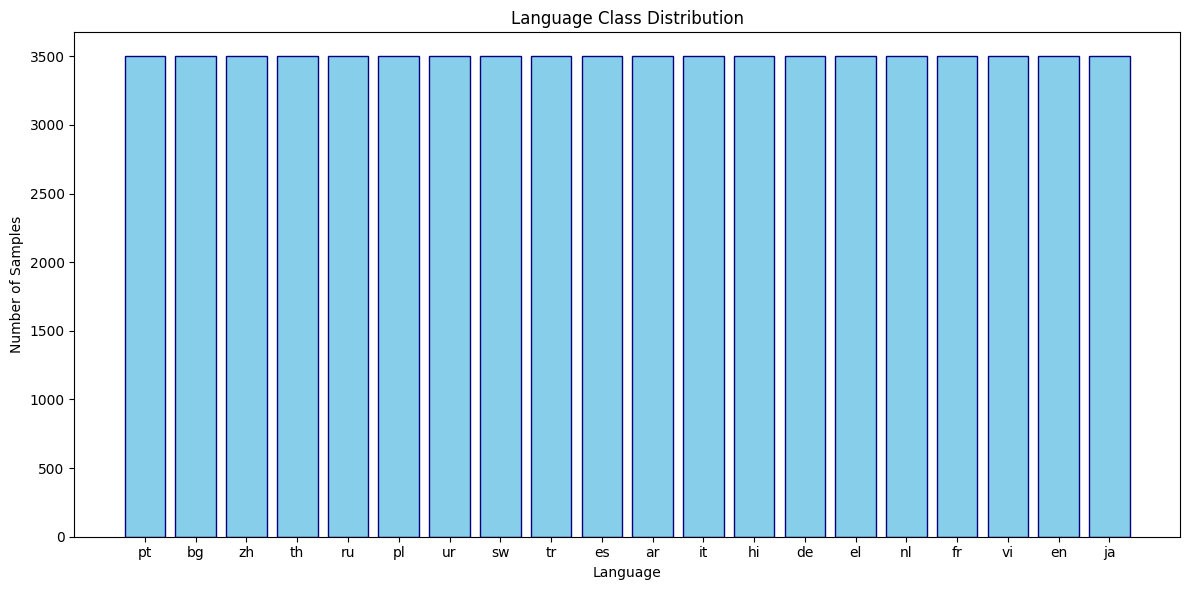

In [6]:
# 3. Class Distribution & Plot
print("\n--- Class Distribution ---")
class_counts = df_train['labels'].value_counts()

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(class_counts.index, class_counts.values, color='skyblue', edgecolor='navy')

plt.title('Language Class Distribution')
plt.xlabel('Language')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

**Conclusion:** The classes are perfectly balanced with 3,500 samples per language, preventing model bias toward any specific language.

### Text Length Analysis
Computing word counts and generating descriptive statistics to understand document length variability.

In [7]:
# 4. Text Length Analysis
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
print("\n--- Word Count Statistics ---")
print(df_train['word_count'].describe())


--- Word Count Statistics ---
count    70000.000000
mean        19.749257
std         19.430456
min          1.000000
25%          7.000000
50%         14.000000
75%         26.000000
max        420.000000
Name: word_count, dtype: float64


**Conclusion:** Text lengths vary significantly, with an average of approximately 20 words per sample.

### Qualitative Data Review
Extracting and printing a text snippet for each language to verify content quality.

In [8]:
print("One text per language:\n")
for lang in languages[:]:
    sample = df_train[df_train["labels"] == lang]["text"].iloc[0]
    print(f"[{lang}]: {sample[:100]}")
    print()

One text per language:

[pt]: os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão 

[bg]: размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до

[zh]: 很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出

[th]: สำหรับ ของเก่า ที่ จริงจัง ลอง   honeychurch   ของเก่า ที่ ไม่   29   สำหรับ เฟอร์นิเจอร์ และ เงิน ไ

[ru]: Он увеличил давление .

[pl]: S Jak sobie życzysz: Widzisz, jak Hitler zabija Żydów?

[ur]: اس کے بارے میں ، سفید شادی کی شرح کے بعد سفید اورنمایاں طور پر سفید اورنمایاں طور پر .

[sw]: Zabuni ya ushindani pia imekuwa rahisi kwa sifa ya kurudi kwenye mapendekezo yake ya grant , na dudo

[tr]: Devasa 12 yüzyıl abbatiale saint-Pierre-Et-Saint-Paul , Aziz Peter ' ın 17 yüzyılda Roma ' da tamaml

[es]: Un producto de una calidad y capacidad increíbles que será el placer de todo amante de la tecnología

[ar]: نعم , هذا صحيح نعم اعتقد ان 

### Preprocessing Logic
Defining a text cleaning pipeline including normalization, lowercasing, and character filtering.

In [9]:
def clean_text(text):

    # 1. Normalise unicode
    text = unicodedata.normalize('NFKC', text)
    # 2. Lowercase
    text = text.lower()
    # 3. Replace digits
    text = re.sub(r'\d+', '<NUM>', text)
    # 4. Keep letters, apostrophe, hyphen, space, and sentence punctuation
    text = re.sub(r'[^\w\s\'\-\.\!\?]', '', text)
    # 5. Collapse spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


### Data Transformation
Applying the cleaning pipeline to the training, validation, and test datasets.

In [10]:
df_train["text_clean"] = df_train["text"].apply(clean_text)
df_val["text_clean"] = df_val["text"].apply(clean_text)
df_test["text_clean"] = df_test["text"].apply(clean_text)



### Post-Cleaning Inspection
Sampling cleaned text to verify that symbols and noise were removed correctly.

In [11]:
df_train["text_clean"].sample(5)

,text_clean
47466,- وتحصل الحكومة الاتحادية وهي اكبر مالك لبناء الدولة على مبان وغيرها من الهياكل لدعم مهام وبعثات محددة وتسيير اعمالها بشكل عام .
40240,NUM-وبمجرد ان كانت احدى عقارات الشاي كانت رائعكيت بوكيت بوكيت ماكسويل هيل على بعد NUM كيلومترا NUM.NUM ميل من الشمال الشرقي من taipin هي اصغر واكبر محطة هيل في ماليزيا و في للمديرين الاستعماري .
11827,quality good not what i expected not for everyday wear
37568,mucha potencia y dura la batería muchísimo
15007,bên trong khu vực phía đông là cái yumedono hành lang của giấc mơ những bức tượng tinh tế guze kannon được coi là rất thiêng liêng rằng nó đã được hoàn toàn ẩn khỏi mắt con người từ sự cống hiến của nó vào năm NUM cho đến NUM khi đó được tổ chức bởi một học giả nghệ thuật của mỹ với sự ban phước của chính phủ meiji tất nhiên .


### Variable Assignment
Splitting text features and target labels into dedicated variables for modeling.

In [12]:
x_train = df_train["text_clean"]
y_train = df_train["labels"]

x_val = df_val["text_clean"]
y_val = df_val["labels"]

x_test = df_test["text_clean"]
y_test = df_test["labels"]

### TF-IDF Vectorization
Converting raw text into numerical features using character n-grams with a capped vocabulary.

In [13]:
# 1. Vectorize with a hard cap of 150,000 features
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5), max_features=150000)
X_train_vec = vectorizer.fit_transform(x_train)
X_val_vec = vectorizer.transform(x_val)
X_test_vec = vectorizer.transform(x_test)

### Feature Verification
Verifying the dimensions of the TF-IDF matrix and the size of the generated vocabulary.

In [14]:
print(f"TF-IDF matrix shape (train): {X_train_vec.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

TF-IDF matrix shape (train): (70000, 150000)
Vocabulary size: 150,000


### Naive Bayes Training
Training a Multinomial Naive Bayes model and evaluating it with accuracy, F1-score, and a confusion matrix.

Start Training MultinomialNB
Validation ml Accuracy: 0.9934 (99.34%)
Validation ml f1_score: 0.9934 (99.34%)
Validation ml recall: 0.9934 (99.34%)
Validation ml precision: 0.9936 (99.36%)
              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.97      1.00      0.99       500
          es       0.99      1.00      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.97       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       0.99      1.00      0.99       500
          pl       1.00      1.00      1.00       500
          pt       1.00      0.98      0.99       500
          ru       1.00      0.99      1.00       500
 

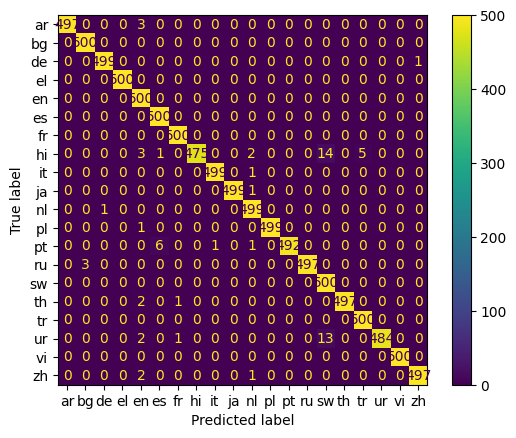

In [17]:
print("Start Training MultinomialNB")
model_ml = MultinomialNB()
model_ml.fit(X_train_vec, y_train)

# Evaluate on validation set
y_val_pred1 = model_ml.predict(X_val_vec)
val_accuracy = accuracy_score(y_val, y_val_pred1)
val_f1_score = f1_score(y_val, y_val_pred1 , average='macro')
val_recall_score = recall_score(y_val, y_val_pred1 , average='macro')
val_precision_score = precision_score(y_val, y_val_pred1 , average='macro')
print(f"Validation ml Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Validation ml f1_score: {val_f1_score:.4f} ({val_f1_score*100:.2f}%)")
print(f"Validation ml recall: {val_recall_score:.4f} ({val_recall_score*100:.2f}%)")
print(f"Validation ml precision: {val_precision_score:.4f} ({val_precision_score*100:.2f}%)")

print(classification_report(y_val, y_val_pred1))

disp = ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred1)



**Conclusion:** The MultinomialNB model performs exceptionally well with over 99% accuracy across all languages.

### Logistic Regression Training
Training a Logistic Regression model and generating detailed classification metrics and a confusion matrix.

Start Training LogisticRegression
Validation lr Accuracy: 0.9931 (99.31%)
Validation lr f1_score: 0.9931 (99.31%)
Validation lr recall: 0.9931 (99.31%)
Validation lr precision: 0.9933 (99.33%)
              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.98      1.00      0.99       500
          es       1.00      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       0.98      1.00      0.99       500
          pl       1.00      1.00      1.00       500
          pt       0.99      1.00      1.00       500
          ru       1.00      0.99      1.00       

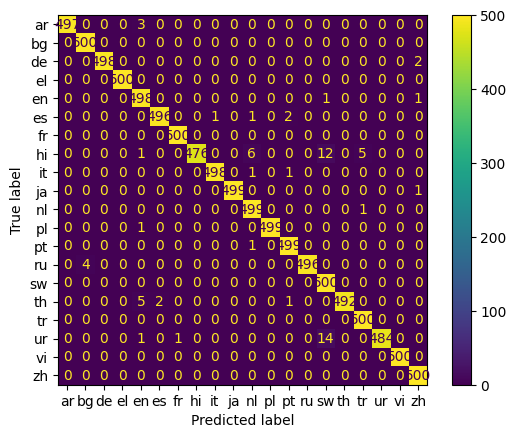

In [18]:
print("Start Training LogisticRegression")
model_lr = LogisticRegression()
model_lr.fit(X_train_vec, y_train)

# Evaluate on validation set
y_val_pred2 = model_lr.predict(X_val_vec)
val_accuracy = accuracy_score(y_val, y_val_pred2)
val_f1_score = f1_score(y_val, y_val_pred2 , average='macro')
val_recall_score = recall_score(y_val, y_val_pred2 , average='macro')
val_precision_score = precision_score(y_val, y_val_pred2 , average='macro')
print(f"Validation lr Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Validation lr f1_score: {val_f1_score:.4f} ({val_f1_score*100:.2f}%)")
print(f"Validation lr recall: {val_recall_score:.4f} ({val_recall_score*100:.2f}%)")
print(f"Validation lr precision: {val_precision_score:.4f} ({val_precision_score*100:.2f}%)")

print(classification_report(y_val, y_val_pred2))

disp = ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred2)

**Conclusion:** Logistic Regression yields comparable results to Naive Bayes, maintaining 99% accuracy.

### Artifact Export
Saving the vectorizer and both trained models to disk for persistence.

In [19]:
import joblib

joblib.dump(vectorizer, 'ang_vectorizer.pkl')
joblib.dump(model_ml, 'ml_lang_model.pkl')
joblib.dump(model_lr, 'lr_lang_model.pkl')

print("\nArtifacts saved successfully!")




Artifacts saved successfully!


### Inference Pipeline
Implementing a function to process new user input and output language predictions with confidence scores.

In [ ]:
model_ml = joblib.load('ml_lang_model.pkl')
vectorizer = joblib.load('ang_vectorizer.pkl')

# 2. Interactive Testing Function for User Input
def test_pipeline(user_input , model):
    # Apply the exact cleaning function we defined earlier
    cleaned = clean_text(user_input)

    # Transform using our 15k feature vectorizer
    vectorized_input = vectorizer.transform([cleaned])

    # Predict language and grab prediction probabilities (confidence score)
    prediction = model.predict(vectorized_input)[0]
    probabilities = model.predict_proba(vectorized_input)[0]

    # Map probabilities to classes
    class_labels = model.classes_
    confidence_dict = {label: f"{prob * 100:.2f}%" for label, prob in zip(class_labels, probabilities)}

    print("\n" + "="*40)
    print(f"Model : {type(model).__name__}")
    # print(f"Raw Input: '{user_input}'")
    # print(f"Cleaned Text: '{cleaned}'")
    print(f"Predicted Class: {prediction}")
    print(f"Confidence Scores: {list(sorted(confidence_dict.items(), key=lambda x: x[1], reverse=True)[:3])}")
    print("="*40)

# 3. Test with custom examples

test_pipeline("""عندنا تصويت شغال حاليا على قناتنا على التلجرام بخصوص تكملة كورس
Advanced n8n with Karim - How to ba an AI Automation Engineer

إذا تحب تشارك في التصويت سارع بالدخول للقناة


Show translation""" , model_ml)

test_pipeline("""ML introduction
• AI vs ML vs DL
• Machine Learning models
• Data Mining vs ML
• ML Workflow / Life-cycle
• Data Cleaning (scrubbing)


ملانترفيوهات الـ ML.""" , model_ml)





Model : MultinomialNB
Predicted Class: ar
Confidence Scores: [(np.str_('ar'), '100.00%'), (np.str_('bg'), '0.00%'), (np.str_('de'), '0.00%')]

Model : MultinomialNB
Predicted Class: en
Confidence Scores: [(np.str_('en'), '90.33%'), (np.str_('nl'), '7.43%'), (np.str_('sw'), '0.74%')]

Model : LogisticRegression
Predicted Class: ar
Confidence Scores: [('ar', '93.76%'), ('ur', '0.93%'), ('sw', '0.76%')]

Model : LogisticRegression
Predicted Class: en
Confidence Scores: [('sw', '7.75%'), ('pl', '7.55%'), ('fr', '5.51%')]


**Conclusion:** The models correctly identify languages in mixed-context inputs with high confidence.
but the MultinomialNB model have good intention understanding about the language